## Avaliando o baseline

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
OCR_DIR = PROJECT_ROOT / "ocr"
EVAL_DIR = PROJECT_ROOT / "evaluation"

# Adiciona a raiz do projeto
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Adiciona a pasta ocr
if str(OCR_DIR) not in sys.path:
    sys.path.insert(0, str(OCR_DIR))

# Adiciona a pasta evaluation
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

from classifier.baseline_quality_estimator import estimate_sharpness
from ocr.service import extract_document
from evaluation.ocr_evaluator import evaluate

In [39]:
import pandas as pd
import json
import tqdm

LABEL_FILE_NAME = "../database/labels/rg_real.json"
OUTPUT_FILE_NAME = '../database/ocr_predictions/tmp.json'

SOURCE_DIRS = [
    Path("../database/labels/ILLEGIBLE"),
    Path("../database/labels/LEGIBLE"),
]

results = []

for source in SOURCE_DIRS:

    for input_img_fn in tqdm.tqdm(source.glob("*")):
        quality_score = estimate_sharpness(str(input_img_fn))

        ocr_result = extract_document(str(input_img_fn))

        # Save the result to a JSON file
        with open(OUTPUT_FILE_NAME, "w") as f:
            json.dump(ocr_result, f)

        ocr_score = evaluate(LABEL_FILE_NAME, OUTPUT_FILE_NAME)

        results.append({
            "sharpness_score": float(quality_score),
            "ocr_score": float(ocr_score['score']),
            "label": Path(input_img_fn).parent.name
        })

df = pd.DataFrame(results)

df.head(3)

25it [02:01,  4.86s/it]
53it [04:20,  4.91s/it]


,sharpness_score,ocr_score,label
0,100.00,76.0,ILEGIBLE
1,90.78,80.0,ILEGIBLE
2,20.72,80.0,ILEGIBLE


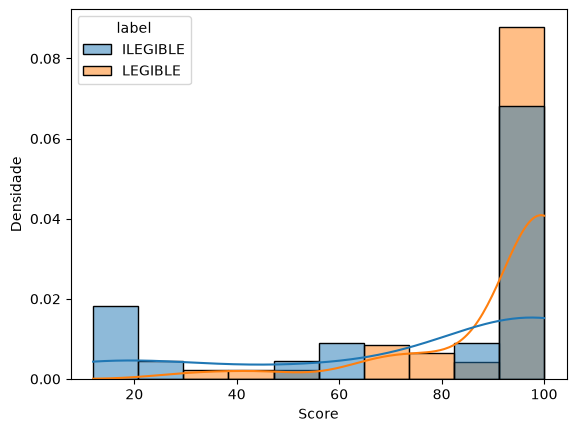

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="sharpness_score",
    hue="label",
    bins=10,
    kde=True,
    stat="density",
    common_norm=False
)

plt.xlabel("Score")
plt.ylabel("Densidade")
plt.show()

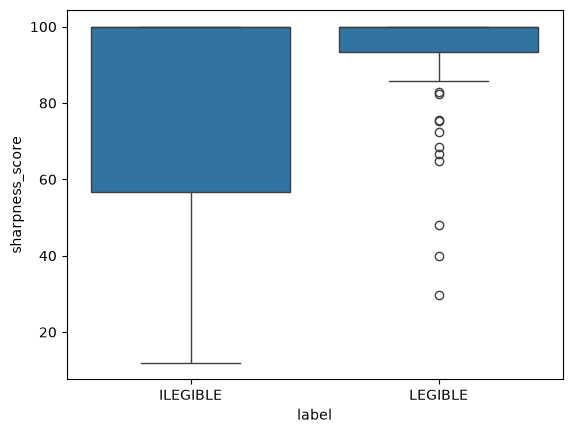

In [42]:
sns.boxplot(
    data=df,
    x="label",
    y="sharpness_score"
)

plt.show()

### Threshold Definition

In [44]:
import numpy as np
from sklearn.metrics import f1_score

scores = np.sort(df["sharpness_score"].unique())

best_threshold = None
best_f1 = -1

y_true = (df["label"] == "LEGIBLE").astype(int)

for t in scores:
    y_pred = (df["sharpness_score"] >= t).astype(int)

    f1 = f1_score(y_true, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f'Best threshold: {best_threshold}\nBest F1: {best_f1}')

Best threshold: 29.79
Best F1: 0.8412698412698413


In [54]:
df['predictions'] = df['sharpness_score'].apply(lambda x: 'LEGIBLE' if x > best_threshold else 'ILLEGIBLE')
df['predictions'].value_counts()

predictions
LEGIBLE      72
ILLEGIBLE     6
Name: count, dtype: int64

## Confusion Matrix

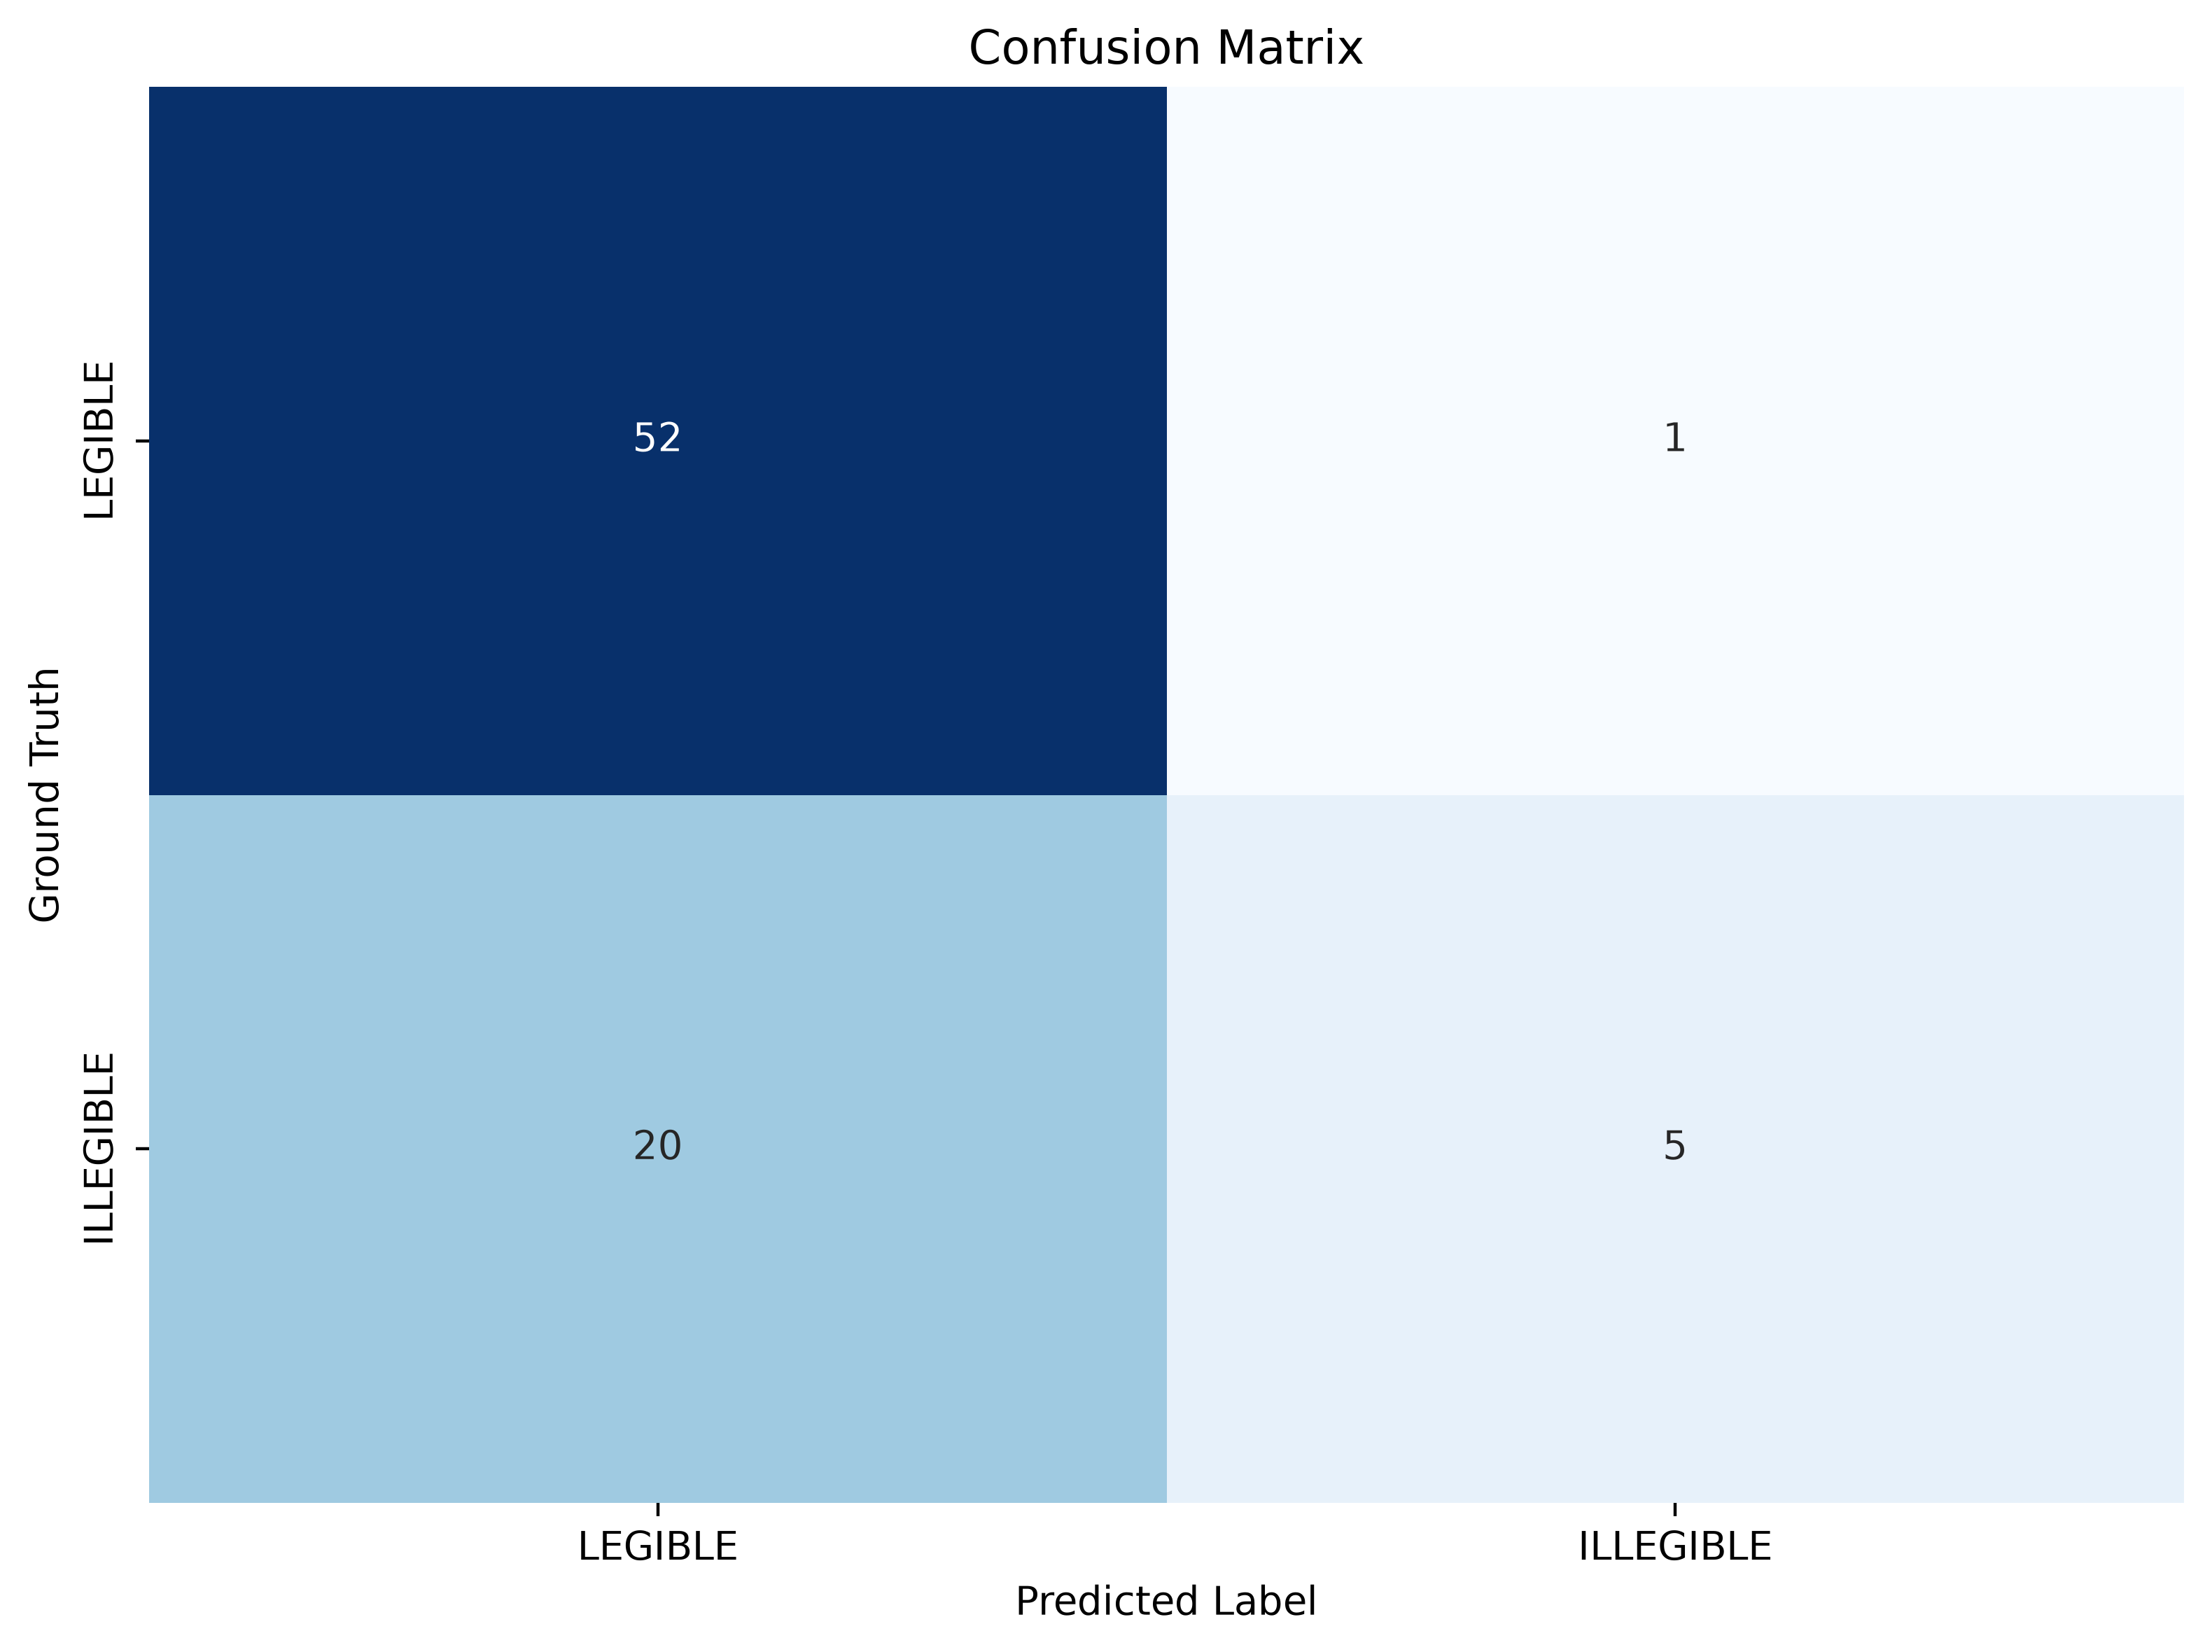

In [61]:
from sklearn.metrics import confusion_matrix

# Matriz de confusão
cm = confusion_matrix(
    y_true=df["label"],
    y_pred=df["predictions"],
    labels=["LEGIBLE", "ILLEGIBLE"]
)

# Plot
#plt.figure(figsize=(6, 5))
plt.figure(figsize=(8, 6), dpi=400)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["LEGIBLE", "ILLEGIBLE"],
    yticklabels=["LEGIBLE", "ILLEGIBLE"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

## AUC 

In [63]:
from sklearn.metrics import roc_curve, auc

y_true = (df["label"] == "LEGIBLE").astype(int)

fpr, tpr, thresholds = roc_curve(
    y_true,
    df["sharpness_score"]
)

roc_auc = auc(fpr, tpr)
roc_auc

0.6162264150943396

## ROC Curve

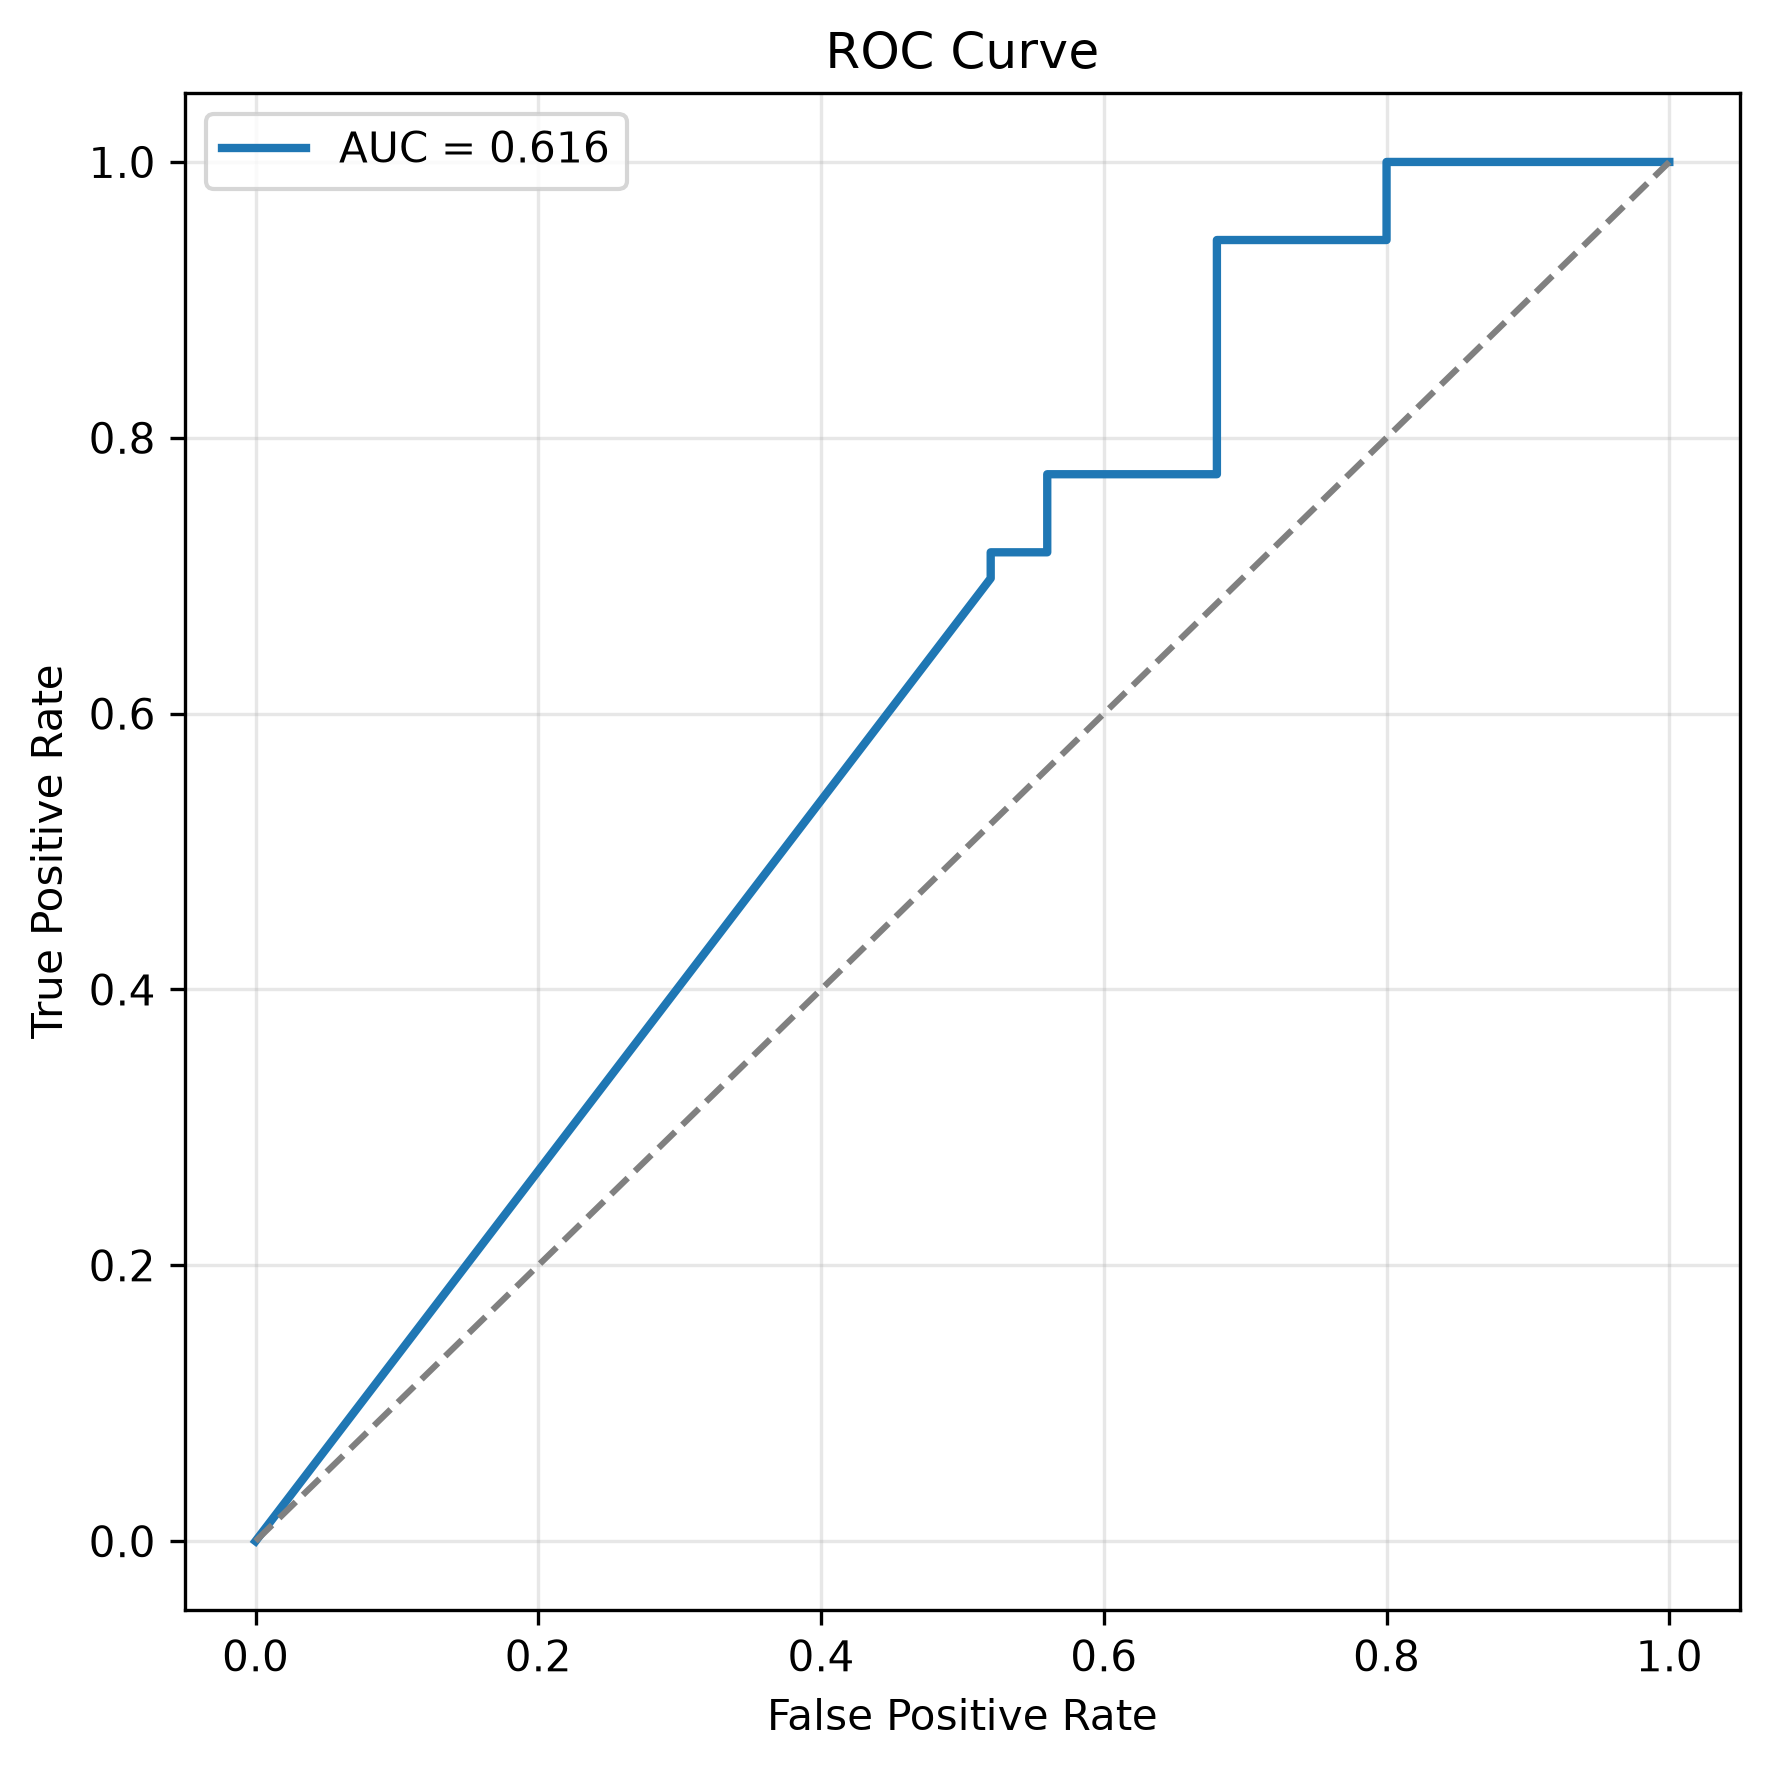

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6), dpi=300)

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()